In [1]:
!pip -q install beautifulsoup4 vaderSentiment textblob wordcloud matplotlib
!python -m textblob.download_corpora

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud
import re

In [3]:
speeches = {
    "George Washington (1789)": "https://millercenter.org/the-presidency/presidential-speeches/april-30-1789-first-inaugural-address",
    "Andrew Jackson (1829)": "https://millercenter.org/the-presidency/presidential-speeches/march-4-1829-first-inaugural-address",
    "William McKinley (1897)": "https://millercenter.org/the-presidency/presidential-speeches/march-4-1897-first-inaugural-address",
    "John F. Kennedy (1961)": "https://millercenter.org/the-presidency/presidential-speeches/january-20-1961-inaugural-address",
    "Donald Trump (2025)": "https://millercenter.org/the-presidency/presidential-speeches/january-20-2025-inaugural-address",
}

In [4]:
def clean_text(text):
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_transcript(url):
    html = requests.get(url, timeout=30).text
    soup = BeautifulSoup(html, "html.parser")

    # pull main page text
    text = soup.get_text("\n")
    lines = [line.strip() for line in text.splitlines() if line.strip()]

    # start at Transcript if possible
    start = 0
    for i, line in enumerate(lines):
        if line.lower() == "transcript":
            start = i + 1
            break

    transcript = "\n".join(lines[start:])

    # trim off obvious footer clutter if present
    stop_words = [
        "Miller Center Foundation",
        "Donate",
        "Copyright",
        "University of Virginia"
    ]
    for stop in stop_words:
        idx = transcript.find(stop)
        if idx != -1:
            transcript = transcript[:idx]

    return clean_text(transcript)

In [5]:
data = []
for president, url in speeches.items():
    text = extract_transcript(url)
    data.append({"President": president, "Text": text})

df = pd.DataFrame(data)
df

,President,Text
0,George Washington (1789),Fellow Citizens of the Senate and the House of...
1,Andrew Jackson (1829),Fellow-Citizens: About to undertake the arduou...
2,William McKinley (1897),Fellow-Citizens: In obedience to the will of t...
3,John F. Kennedy (1961),"Vice President Johnson, Mr. Speaker, Mr. Chief..."
4,Donald Trump (2025),"THE PRESIDENT: Thank you. Thank you very much,..."


In [6]:
analyzer = SentimentIntensityAnalyzer()

df["VADER"] = df["Text"].apply(lambda x: analyzer.polarity_scores(x)["compound"])
df["TextBlob"] = df["Text"].apply(lambda x: TextBlob(x).sentiment.polarity)

df[["President", "VADER", "TextBlob"]]

,President,VADER,TextBlob
0,George Washington (1789),0.9999,0.201200
1,Andrew Jackson (1829),0.9996,0.116711
2,William McKinley (1897),1.0000,0.195861
3,John F. Kennedy (1961),0.9990,0.150712
4,Donald Trump (2025),0.9999,0.147723


In [ ]:
plot_df = df.set_index("President")[["VADER", "TextBlob"]]
plot_df.plot(kind="bar", figsize=(12,6))
plt.ylabel("Sentiment Score")
plt.title("Sentiment of Five Presidential Inaugural Addresses")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

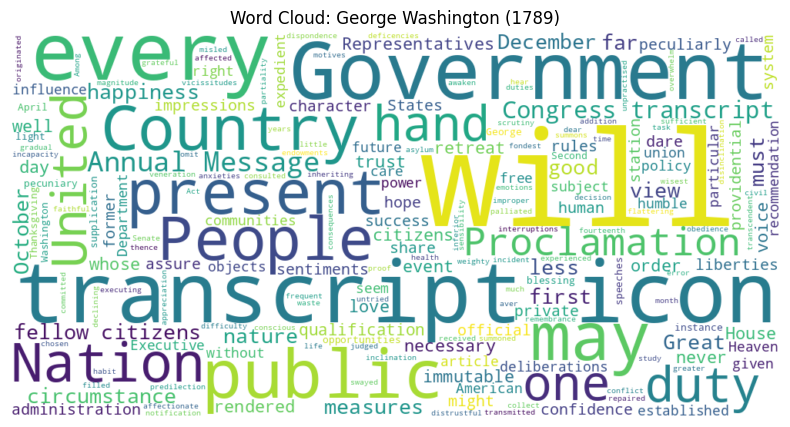

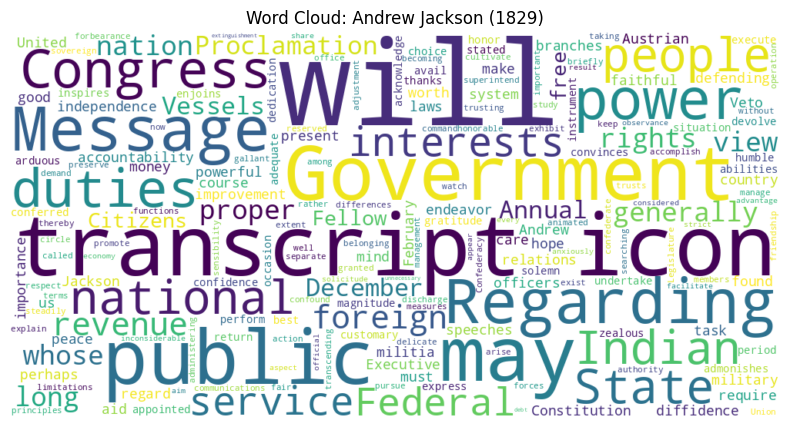

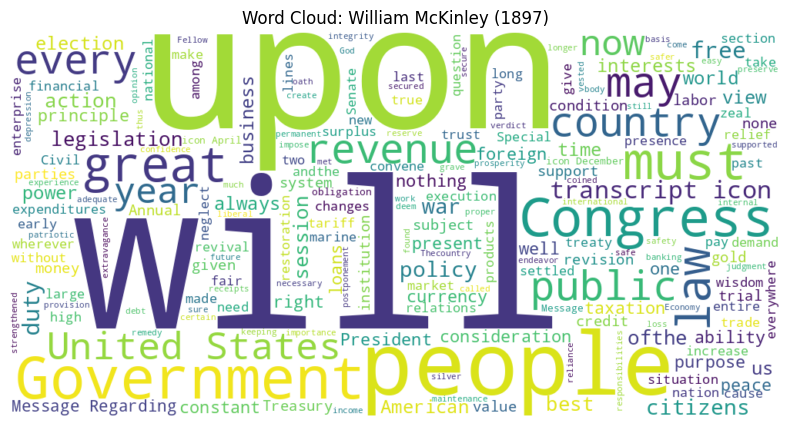

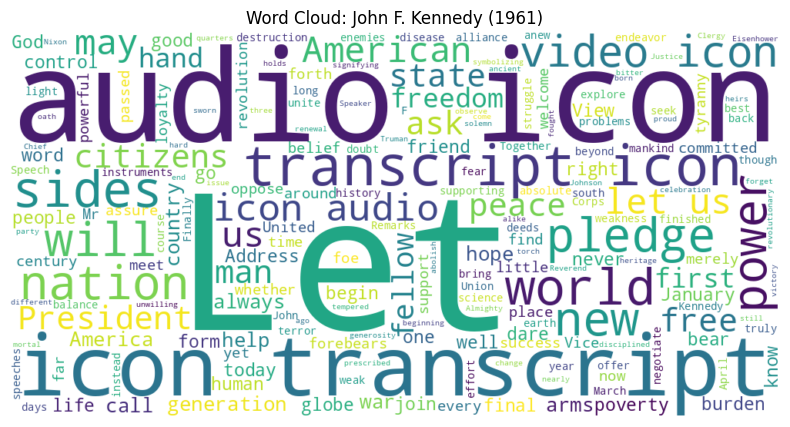

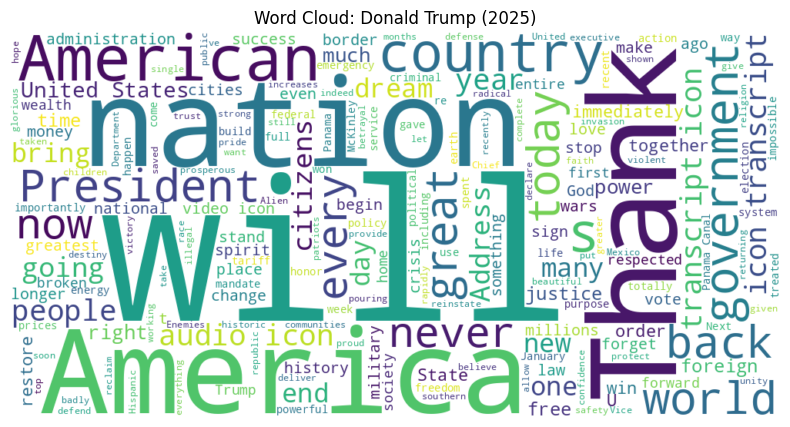

In [7]:
for _, row in df.iterrows():
    wc = WordCloud(width=1000, height=500, background_color="white").generate(row["Text"])
    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud: {row['President']}")
    plt.show()